# Baseline vs Fine-Tuned Training Data Comparison

This notebook demonstrates the difference between:
- **Stage 1 (Baseline)**: Original RGB PCB images without any augmentation
- **Stage 2 (Fine-Tuning)**: Images with lithography-based augmentation (p=0.5)

The lithography augmentation includes:
1. **SEM-style conversion**: Grayscale + color remap + Gaussian blur (σ=0.05) + noise + grain + vignetting
2. **Optical lithography simulation**: Airy disk PSF convolution (wavelength=193nm, NA=1.2) for physical optical blur

In [1]:
# Imports and configuration
import os
import json
import random
from collections import defaultdict
import numpy as np
import torch
from torch.utils.data import Dataset
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
from scipy.signal import fftconvolve
from scipy.special import j1

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_ROOT = "."
TRAIN_JSON = os.path.join(DATA_ROOT, "train", "_annotations.coco.json")

print("Imports loaded successfully!")

Imports loaded successfully!


In [2]:
# Dataset loading utilities
def load_coco_annotations(ann_path):
    with open(ann_path, "r") as f:
        coco = json.load(f)
    images = coco.get("images", [])
    annotations = coco.get("annotations", [])
    categories = coco.get("categories", [])

    image_id_to_info = {img["id"]: img for img in images}
    image_id_to_anns = defaultdict(list)
    for ann in annotations:
        image_id_to_anns[ann["image_id"]].append(ann)

    categories_by_id = {c["id"]: c for c in categories}
    return image_id_to_info, image_id_to_anns, categories_by_id


class PCBDefectsCocoDataset(Dataset):
    def __init__(self, root_dir, ann_path, transforms=None, one_class=True):
        self.root_dir = root_dir
        self.ann_path = ann_path
        self.transforms = transforms
        self.one_class = one_class

        self.image_id_to_info, self.image_id_to_anns, self.categories = load_coco_annotations(ann_path)
        self.images = list(self.image_id_to_info.values())

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        image_id = img_info["id"]
        file_name = img_info["file_name"]

        images_dir = os.path.dirname(self.ann_path)
        img_path = os.path.join(images_dir, file_name)

        img = Image.open(img_path).convert("RGB")

        anns = self.image_id_to_anns.get(image_id, [])
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(1 if self.one_class else int(ann["category_id"]) + 1)
            areas.append(ann.get("area", w * h))
            iscrowd.append(ann.get("iscrowd", 0))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32) if areas else torch.zeros((0,), dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64) if iscrowd else torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id]),
            "area": areas,
            "iscrowd": iscrowd,
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target


print("Dataset utilities loaded!")

Dataset utilities loaded!


In [3]:
# Lithography augmentation functions (from training notebook)

def convert_to_sem_style(img):
    """Apply SEM-style conversion with blur, noise, and grain."""
    img_gray = img.convert("L")
    img_array = np.array(img_gray).astype(float) / 255.0

    # Color remap: 0 -> 124/255, 1 -> 57/255
    img_remapped = img_array * (-67 / 255.0) + (124 / 255.0)

    # Gaussian blur (sigma=0.05) - THIS IS THE BLUR!
    img_blur = ndimage.gaussian_filter(img_remapped, sigma=0.05)

    # Noise
    noise = np.random.normal(0, 0.015, img_blur.shape)
    img_noisy = img_blur + noise
    img_noisy = np.clip(img_noisy, 0.0, 1.0)

    # Fine grain texture
    grain_size = 2
    grain = np.random.normal(0, 0.01, (img_noisy.shape[0] // grain_size, img_noisy.shape[1] // grain_size))
    grain_upscaled = ndimage.zoom(grain, grain_size, order=1)
    if grain_upscaled.shape != img_noisy.shape:
        grain_upscaled = grain_upscaled[: img_noisy.shape[0], : img_noisy.shape[1]]
    img_grain = img_noisy + grain_upscaled
    img_grain = np.clip(img_grain, 0.0, 1.0)

    # Vignetting
    rows, cols = img_grain.shape
    y, x = np.ogrid[:rows, :cols]
    center_y, center_x = rows / 2, cols / 2
    max_dist = np.sqrt(center_y ** 2 + center_x ** 2)
    dist_from_center = np.sqrt((y - center_y) ** 2 + (x - center_x) ** 2)
    vignette = 1 - 0.06 * (dist_from_center / max_dist) ** 2
    img_sem = img_grain * vignette

    img_sem = np.clip(img_sem, 0.0, 1.0)
    img_sem = (img_sem * 255).astype(np.uint8)
    return Image.fromarray(img_sem)


def simulate_lithography(img, wavelength=193, na=1.2, defocus=0, dose=1.0):
    """Optical lithography simulation with Airy disk PSF (physical blur)."""
    img_gray = img.convert("L")
    mask = np.array(img_gray).astype(float) / 255.0
    mask_pattern = mask

    # Optical PSF - THIS ADDS PHYSICAL OPTICAL BLUR!
    resolution_limit = wavelength / (2 * na)
    pixel_scale = 10  # nm per pixel
    psf_radius_pixels = int(resolution_limit / pixel_scale)
    psf_radius_pixels = max(5, min(psf_radius_pixels, 50))

    y, x = np.ogrid[-psf_radius_pixels : psf_radius_pixels + 1, -psf_radius_pixels : psf_radius_pixels + 1]
    r = np.sqrt(x ** 2 + y ** 2)

    v = 2 * np.pi * na * r * pixel_scale / wavelength
    v[v == 0] = 1e-10
    airy = (2 * j1(v) / v) ** 2
    airy = airy / airy.sum()

    if defocus != 0:
        defocus_phase = np.pi * na ** 2 * (r * pixel_scale) ** 2 * defocus / wavelength ** 2
        defocus_kernel = np.cos(defocus_phase)
        airy = airy * (1 + 0.5 * defocus_kernel)
        airy = airy / airy.sum()

    # FFT convolution - applies the blur
    aerial_image = fftconvolve(mask_pattern, airy, mode="same")
    aerial_image = np.clip(aerial_image, 0.0, 1.0)

    # Resist simulation
    exposure = aerial_image * dose
    resist_contrast = 5.0
    threshold = 0.5
    developed_resist = 1 / (1 + np.exp(-resist_contrast * (exposure - threshold)))

    # Process variations
    ler_noise = np.random.normal(0, 0.02, developed_resist.shape)
    developed_resist = np.clip(developed_resist + ler_noise, 0, 1)

    defect_probability = 0.001
    defect_mask = np.random.random(developed_resist.shape) < defect_probability
    if defect_mask.any():
        developed_resist[defect_mask] = np.random.uniform(0.3, 0.7, np.sum(defect_mask))

    final_pattern = (developed_resist * 255).astype(np.uint8)
    return Image.fromarray(final_pattern)


def apply_lithography_augmentation(img):
    """Apply full lithography pipeline: SEM + optical simulation."""
    sem_img = convert_to_sem_style(img)
    wafer_img = simulate_lithography(sem_img, wavelength=193, na=1.2, defocus=0, dose=1.0)
    wafer_img_rgb = wafer_img.convert("RGB")
    return wafer_img_rgb


print("Lithography augmentation functions loaded!")

Lithography augmentation functions loaded!


In [4]:
# Load training dataset (baseline - no transforms)
class NoTransform:
    """Identity transform - returns PIL image as-is."""
    def __call__(self, img, target):
        return img, target

train_dataset_baseline = PCBDefectsCocoDataset(
    root_dir=DATA_ROOT,
    ann_path=TRAIN_JSON,
    transforms=NoTransform(),
    one_class=True,
)

print(f"Loaded {len(train_dataset_baseline)} training images")

Loaded 1053 training images


Generating side-by-side comparison...


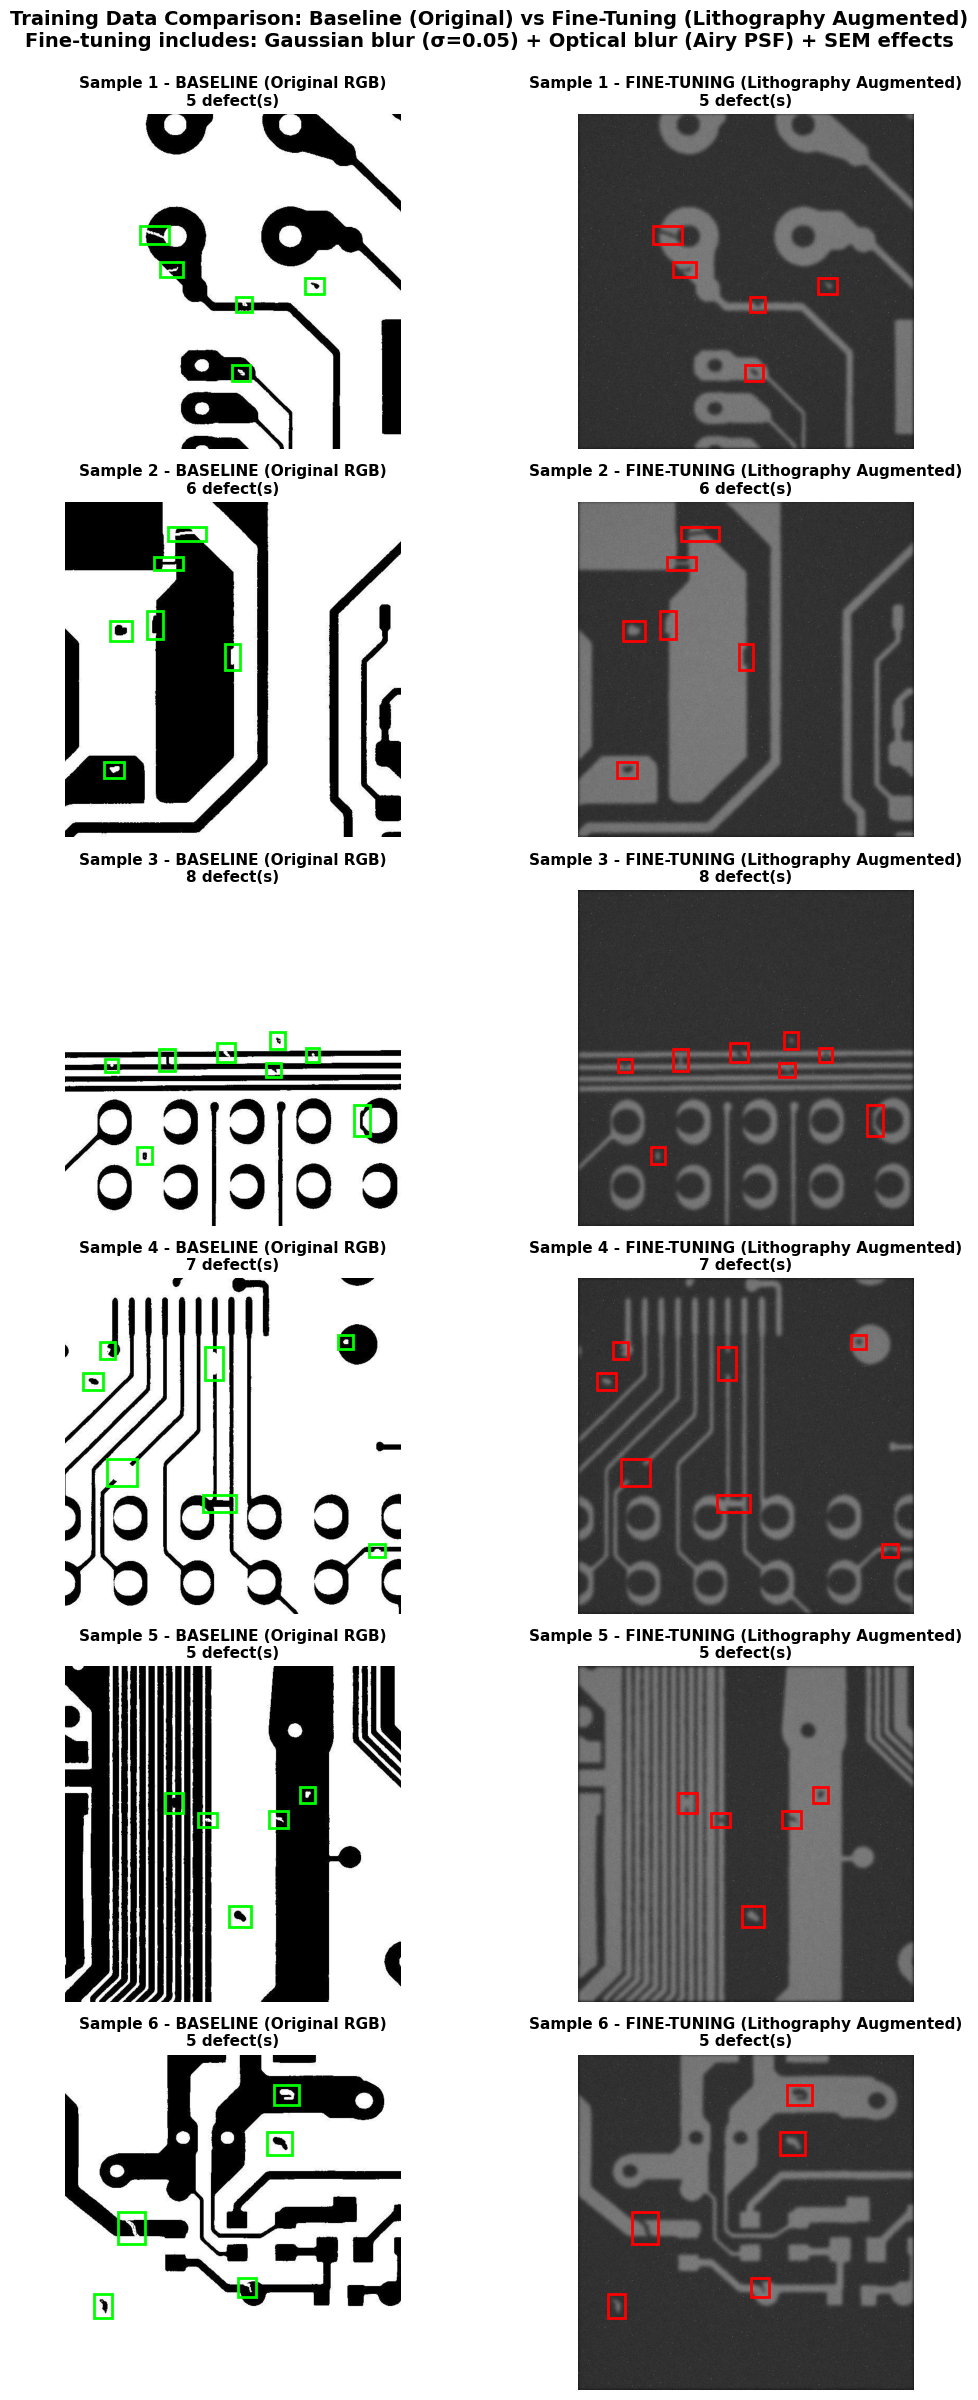


SUMMARY:
✓ BASELINE MODEL (Stage 1):
  - Uses original RGB PCB images
  - NO blur, NO augmentation
  - Bounding boxes shown in GREEN

✓ FINE-TUNED MODEL (Stage 2):
  - Uses lithography-augmented images (p=0.5 probability)
  - Includes TWO types of blur:
    1. Gaussian blur (σ=0.05) in SEM conversion
    2. Optical blur (Airy disk PSF, wavelength=193nm, NA=1.2)
  - Also includes: grayscale conversion, color remap, noise, grain, vignetting
  - Bounding boxes shown in RED
  - Bounding boxes remain UNCHANGED (no geometric transforms)


In [5]:
# Visualize: Baseline (original) vs Fine-tuning (augmented) training data

num_samples = 6
rows = num_samples
cols = 2  # Column 1: Baseline (original), Column 2: Fine-tuning (augmented)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * num_samples))

print("Generating side-by-side comparison...")

for i in range(num_samples):
    # Get original image
    img_baseline, target = train_dataset_baseline[i]
    img_baseline_np = np.array(img_baseline)
    
    # Apply lithography augmentation
    img_augmented = apply_lithography_augmentation(img_baseline)
    img_augmented_np = np.array(img_augmented)
    
    boxes = target["boxes"].numpy()
    num_defects = len(boxes)
    
    # Left column: Baseline (original RGB image)
    ax_baseline = axes[i, 0]
    ax_baseline.imshow(img_baseline_np)
    ax_baseline.set_title(f"Sample {i+1} - BASELINE (Original RGB)\n{num_defects} defect(s)", 
                          fontsize=11, fontweight="bold")
    ax_baseline.axis("off")
    
    for (x1, y1, x2, y2) in boxes:
        w = x2 - x1
        h = y2 - y1
        rect = plt.Rectangle((x1, y1), w, h, fill=False, color="lime", linewidth=2)
        ax_baseline.add_patch(rect)
    
    # Right column: Fine-tuning (augmented with lithography)
    ax_augmented = axes[i, 1]
    ax_augmented.imshow(img_augmented_np)
    ax_augmented.set_title(f"Sample {i+1} - FINE-TUNING (Lithography Augmented)\n{num_defects} defect(s)", 
                           fontsize=11, fontweight="bold")
    ax_augmented.axis("off")
    
    for (x1, y1, x2, y2) in boxes:
        w = x2 - x1
        h = y2 - y1
        rect = plt.Rectangle((x1, y1), w, h, fill=False, color="red", linewidth=2)
        ax_augmented.add_patch(rect)

plt.suptitle("Training Data Comparison: Baseline (Original) vs Fine-Tuning (Lithography Augmented)\n" +
             "Fine-tuning includes: Gaussian blur (σ=0.05) + Optical blur (Airy PSF) + SEM effects",
             fontsize=14, fontweight="bold", y=0.998)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("SUMMARY:")
print("="*80)
print("✓ BASELINE MODEL (Stage 1):")
print("  - Uses original RGB PCB images")
print("  - NO blur, NO augmentation")
print("  - Bounding boxes shown in GREEN")
print()
print("✓ FINE-TUNED MODEL (Stage 2):")
print("  - Uses lithography-augmented images (p=0.5 probability)")
print("  - Includes TWO types of blur:")
print("    1. Gaussian blur (σ=0.05) in SEM conversion")
print("    2. Optical blur (Airy disk PSF, wavelength=193nm, NA=1.2)")
print("  - Also includes: grayscale conversion, color remap, noise, grain, vignetting")
print("  - Bounding boxes shown in RED")
print("  - Bounding boxes remain UNCHANGED (no geometric transforms)")
print("="*80)